In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import gsw
import colormaps as cmaps
import matplotlib.colors as mcolors
from tqdm import tqdm

from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ice_area = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/full_ice_area.nc').__xarray_dataarray_variable__

All local maxima of U statistic:
-----------------------------------------------------------------
  2015-11  |U| = 11075.0  p = 0.0000  *  SIGNIFICANT
  2021-03  |U| = 2845.0  p = 0.7083  
  2010-10  |U| = 1395.0  p = 1.5583  
  2001-02  |U| = 907.0  p = 1.7997  
  2004-06  |U| = 677.0  p = 1.8858  
  2003-06  |U| = 499.0  p = 1.9371  
  1996-06  |U| = 101.0  p = 1.9974  
  1995-01  |U| = 16.0  p = 1.9999  

Selected breakpoint : 2015-11
K (|U| at break)    : 11075.0
p-value             : 0.0000  →  Significant
Mean before         : 0.1985
Mean after          : -0.5298
Shift               : -0.7283


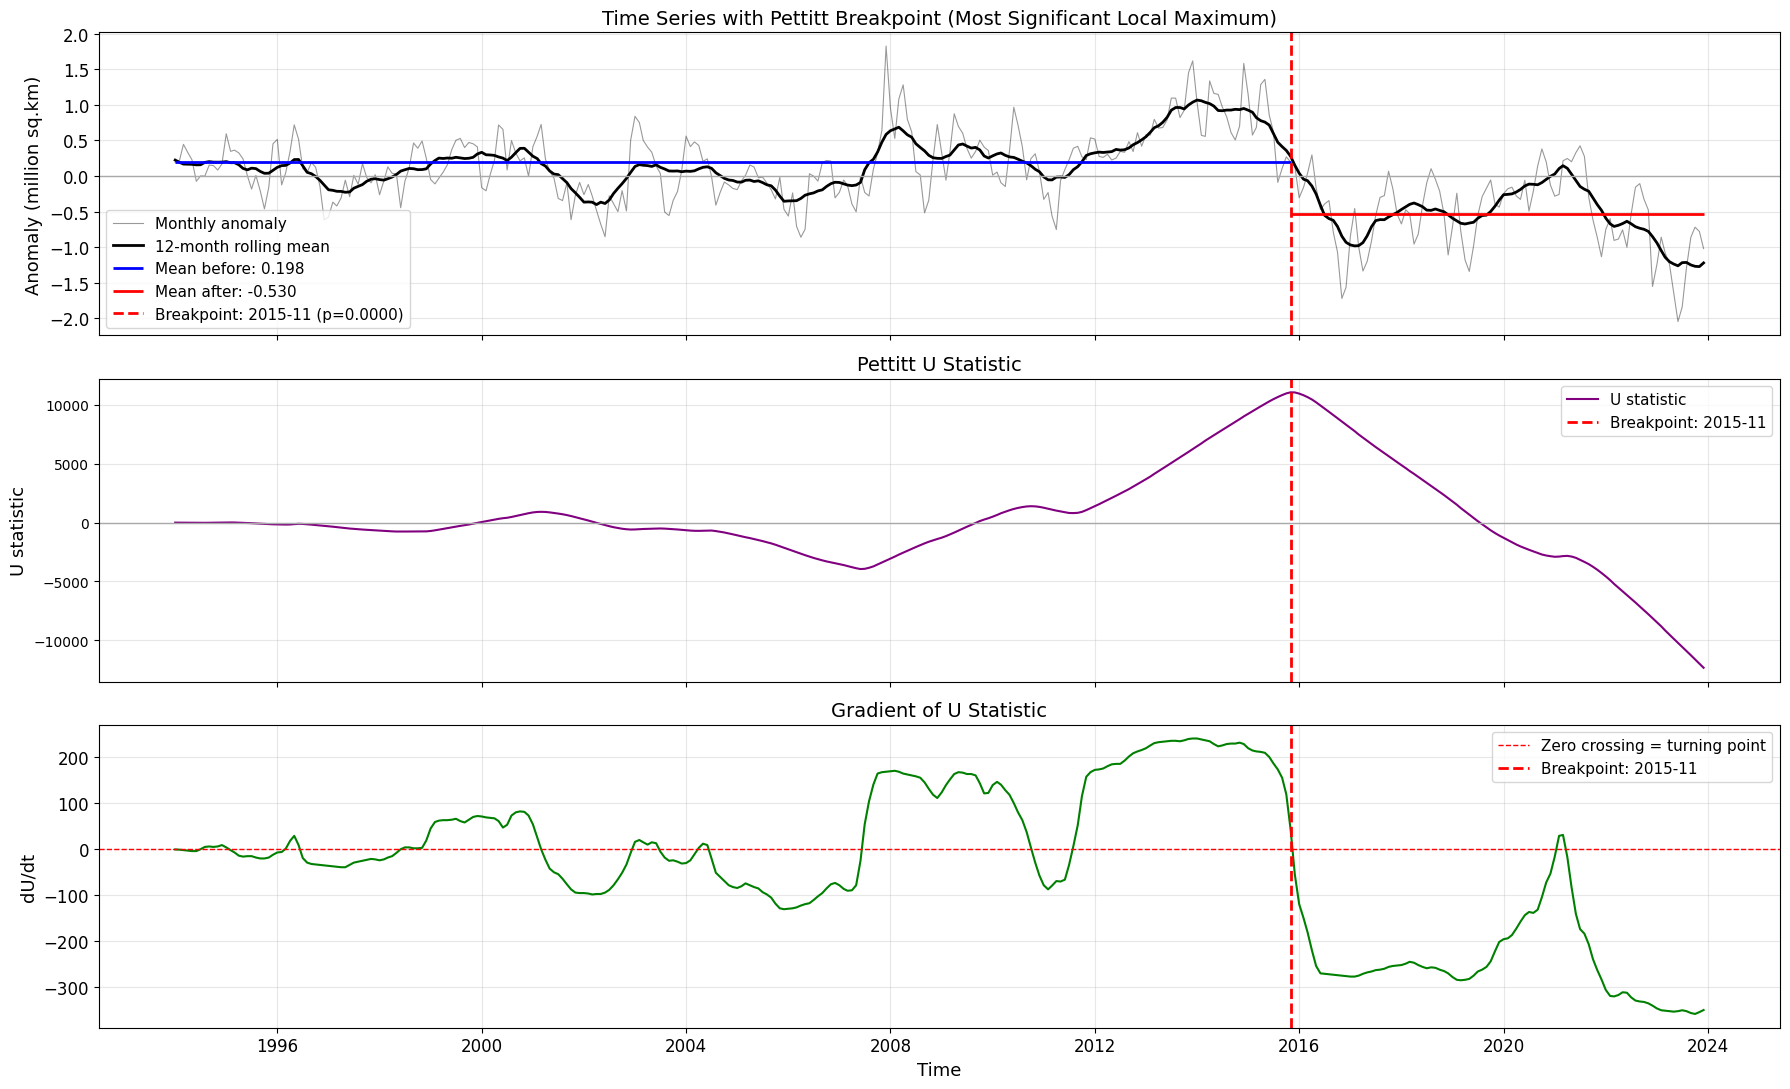

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ts = ice_area.sel(lat=slice(-90,-60),lon=slice(-180,180)).sum(['lat','lon'])*1e-6
ts = ts.sel(time=slice('1994-01','2023-12'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PETTITT TEST FUNCTION
# ============================================================
def pettitt_test(x):
    n = len(x)
    U = np.zeros(n)
    for t in range(1, n):
        U[t] = U[t-1] + np.sum(np.sign(x[t] - x[:t]))
    K       = np.max(np.abs(U))
    t_break = np.argmax(np.abs(U))
    p       = 2 * np.exp(-6 * K**2 / (n**3 + n**2))
    return t_break, K, p, U

# ============================================================
# PREP: deseasonalize + restrict to Argo era
# ============================================================
monthly_clim = ts.groupby('time.month').mean('time')
ts_anom      = ts.groupby('time.month') - monthly_clim
values       = ts_anom.values
time         = pd.to_datetime(ts_anom['time'].values)
mask         = ~np.isnan(values)
values_clean = values[mask]
time_clean   = time[mask]

mask_argo   = (time_clean >= pd.Timestamp('1994-01-01'))
values_argo = values_clean[mask_argo]
time_argo   = time_clean[mask_argo]

# ============================================================
# 12-MONTH ROLLING MEAN
# ============================================================
ts_series  = pd.Series(values_argo, index=time_argo)
ts_rolling = ts_series.rolling(window=12, center=True, min_periods=6).mean()
mask_roll  = ~ts_rolling.isna()
values_roll = ts_rolling[mask_roll].values
time_roll   = ts_rolling[mask_roll].index

# ============================================================
# PETTITT TEST ON SMOOTHED SERIES
# ============================================================
t_pett, K_pett, p_pett, U_pett = pettitt_test(values_roll)

# ============================================================
# FIND MOST SIGNIFICANT LOCAL MAXIMUM
# ============================================================
dU           = np.gradient(U_pett)
sign_changes = np.where(np.diff(np.sign(dU)))[0]
n            = len(values_roll)

# Collect all local maxima with p-values
local_maxima = []
for idx in sign_changes:
    if dU[idx] > 0:  # local max only
        p_local = 2 * np.exp(-6 * np.abs(U_pett[idx])**2 / (n**3 + n**2))
        local_maxima.append((idx, time_roll[idx], np.abs(U_pett[idx]), p_local))

# Sort by |U| descending → most significant first
local_maxima_sorted = sorted(local_maxima, key=lambda x: x[2], reverse=True)

# Report all local maxima
print("All local maxima of U statistic:")
print("-" * 65)
for idx, date, absU, p_loc in local_maxima_sorted:
    print(f"  {date.strftime('%Y-%m')}  |U| = {absU:.1f}  p = {p_loc:.4f}  "
          f"{'*  SIGNIFICANT' if p_loc < 0.05 else ''}")

# Select most significant (highest |U|)
best_idx, break_date, best_U, best_p = local_maxima_sorted[0]

mean_before = np.nanmean(values_roll[:best_idx])
mean_after  = np.nanmean(values_roll[best_idx:])

print(f"\nSelected breakpoint : {break_date.strftime('%Y-%m')}")
print(f"K (|U| at break)    : {best_U:.1f}")
print(f"p-value             : {best_p:.4f}  →  {'Significant' if best_p < 0.05 else 'Not significant'}")
print(f"Mean before         : {mean_before:.4f}")
print(f"Mean after          : {mean_after:.4f}")
print(f"Shift               : {mean_after - mean_before:.4f}")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

# --- Panel 1: Raw anomaly + smoothed + breakpoint ---
ax = axes[0]
ax.plot(time_argo, values_argo, color='black', lw=0.8, alpha=0.4, label='Monthly anomaly')
ax.plot(time_roll, values_roll, color='black', lw=2,   label='12-month rolling mean')
ax.hlines(mean_before, time_roll[0],  break_date,    color='blue', lw=2,
          label=f'Mean before: {mean_before:.3f}')
ax.hlines(mean_after,  break_date,    time_roll[-1], color='red',  lw=2,
          label=f'Mean after: {mean_after:.3f}')
ax.axvline(break_date, color='red', lw=2, ls='--',
           label=f'Breakpoint: {break_date.strftime("%Y-%m")} (p={best_p:.4f})')
ax.axhline(0, color='darkgrey', lw=1)
ax.set_ylabel(r'Anomaly (million sq.km)', fontsize=13)
ax.set_title('Time Series with Pettitt Breakpoint (Most Significant Local Maximum)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)

# --- Panel 2: U statistic ---
ax = axes[1]
ax.plot(time_roll, U_pett, color='purple', lw=1.5, label='U statistic')
ax.axhline(0, color='darkgrey', lw=1)
ax.axvline(break_date, color='red', lw=2, ls='--',
           label=f'Breakpoint: {break_date.strftime("%Y-%m")}')
# Mark all local maxima
# for idx, date, absU, p_loc in local_maxima:
#     color = 'red' if p_loc < 0.05 else 'grey'
#     ax.axvline(date, color=color, lw=1.2, ls=':', alpha=0.7)
ax.set_ylabel('U statistic', fontsize=13)
ax.set_title(f'Pettitt U Statistic', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
# ax.tick_params(labelsize=12)

# --- Panel 3: Gradient of U ---
ax = axes[2]
ax.plot(time_roll, dU, color='green', lw=1.5)
ax.axhline(0, color='red', lw=1, ls='--', label='Zero crossing = turning point')
ax.axvline(break_date, color='red', lw=2, ls='--',
           label=f'Breakpoint: {break_date.strftime("%Y-%m")}')
ax.set_ylabel('dU/dt', fontsize=13)
ax.set_title('Gradient of U Statistic', fontsize=14)
ax.set_xlabel('Time', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/pettitt_test_sea_ice.jpg', dpi=2000, bbox_inches='tight')
plt.show()

Total Southern Ocean profiles : 1219390
Pre-2016                       : 619128
Post-2016                      : 600262


/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


Text(0.5, 0.98, 'Argo Float Profile Density')

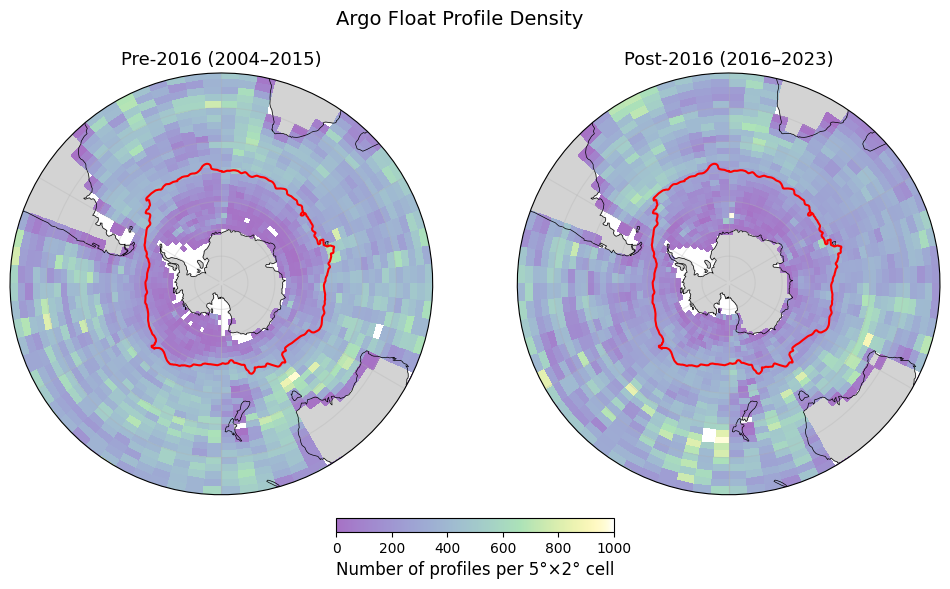

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import colormaps as cmaps

pf_lats = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF
abs_salt = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/abs_salt.nc').salinity

import numpy as np
from scipy.interpolate import interp1d
pf_lons_wrapped = np.mod(pf_lons, 360)
pf_interp = interp1d(pf_lons_wrapped, pf_lats, kind='linear', bounds_error=False, fill_value='extrapolate')
pf_lat_on_en4 = pf_interp(abs_salt.lon.values)
LAT, LON = np.meshgrid(abs_salt.lat.values, abs_salt.lon.values, indexing='ij')
pf_lat_2d = np.tile(pf_lat_on_en4, (LAT.shape[0], 1))
south_of_pf_mask = LAT <= pf_lat_2d

# ============================================================
# LOAD ARGO INDEX
# ============================================================
argo = pd.read_csv('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/argo_float_trajs/ar_index_global_prof.txt',
    comment='#',
    names=['file','date','lat','lon','ocean','profiler','inst','update'],
    low_memory=False
)

# Convert to numeric — coerce errors turns bad strings into NaN
argo['lat']  = pd.to_numeric(argo['lat'],  errors='coerce')
argo['lon']  = pd.to_numeric(argo['lon'],  errors='coerce')
argo['date'] = pd.to_datetime(argo['date'].astype(str),
                               format='%Y%m%d%H%M%S', errors='coerce')

argo = argo.dropna(subset=['date','lat','lon'])

# Restrict to Argo era
argo = argo[(argo['date'] >= pd.Timestamp('2004-01-01')) &
            (argo['date'] <= pd.Timestamp('2023-12-31'))]

# Southern Ocean mask
so   = argo[(argo['lat'] < -10) & (argo['lat'] > -90)]

# Split pre/post 2016
pre  = so[so['date'] <  pd.Timestamp('2016-01-01')]
post = so[so['date'] >= pd.Timestamp('2016-01-01')]

print(f"Total Southern Ocean profiles : {len(so)}")
print(f"Pre-2016                       : {len(pre)}")
print(f"Post-2016                      : {len(post)}")

# ============================================================
# MAP OF PROFILE DENSITY PRE VS POST
# ============================================================
lon_bins = np.arange(-180, 181, 5)
lat_bins = np.arange(-90,  -10, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                          subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax, data, title in zip(axes,
                            [pre, post],
                            ['Pre-2016 (2004–2015)', 'Post-2016 (2016–2023)']):

    ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      color='lightgrey')
    ax.add_feature(cfeature.COASTLINE, lw=0.5)
    ax.gridlines(draw_labels=False, alpha=0.3)
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    # 2D histogram
    h, xedges, yedges = np.histogram2d(
        data['lon'].values,
        data['lat'].values,
        bins=[lon_bins, lat_bins]
    )
    h = np.ma.masked_where(h == 0, h)

    # Use bin centres for pcolormesh
    xcentres = 0.5 * (xedges[:-1] + xedges[1:])
    ycentres = 0.5 * (yedges[:-1] + yedges[1:])
    lon2d, lat2d = np.meshgrid(xcentres, ycentres)

    im = ax.pcolormesh(xedges, yedges, h.T,
                       transform=ccrs.PlateCarree(),
                       cmap=cmaps.cool_light_r, vmin=0, vmax=1000)
    ax.set_title(title, fontsize=13)
    ax.plot(pf_lons_wrapped, pf_lats, color='red', linewidth=1.5,
         transform=ccrs.PlateCarree(), zorder=2)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    pad=0.05, fraction=0.03, shrink=0.6)
cbar.set_label('Number of profiles per 5°×2° cell', fontsize=12)

plt.suptitle('Argo Float Profile Density', fontsize=14)
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/argo_coverage_map.jpg', dpi=500, bbox_inches='tight')
# plt.show()

/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


Pre-2016 (2004–2015)
  100% monthly coverage : 0.0%
  >75% coverage         : 10.2%
  >50% coverage         : 36.5%



/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/tmp/ipykernel_308592/4016711370.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Post-2016 (2016–2023)
  100% monthly coverage : 0.2%
  >75% coverage         : 26.9%
  >50% coverage         : 46.6%

Pre-2016 (2004–2015)
  Fraction of ocean grid cells with 100% monthly coverage: 0.0%
  Fraction with >50% monthly coverage: 26.4%
Post-2016 (2016–2023)
  Fraction of ocean grid cells with 100% monthly coverage: 0.2%
  Fraction with >50% monthly coverage: 33.7%


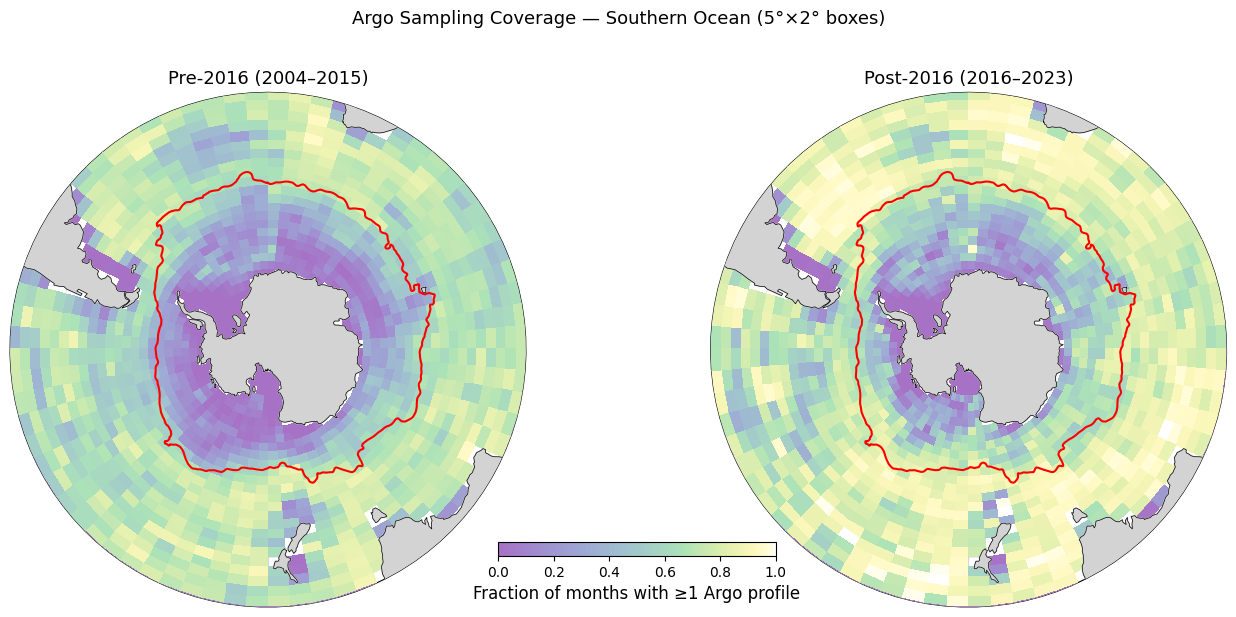

In [5]:
import numpy as np
import pandas as pd
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ============================================================
# 5° x 2° BOX GRID
# ============================================================
lon_bins = np.arange(-180, 181, 5)
lat_bins = np.arange(-90,  0, 2)

lon_grid = 0.5 * (lon_bins[:-1] + lon_bins[1:])
lat_grid = 0.5 * (lat_bins[:-1] + lat_bins[1:])

nlat = len(lat_grid)
nlon = len(lon_grid)

# ============================================================
# BUILD LAND MASK ON 5x2 GRID
# ============================================================
import shapely
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.ops import unary_union
import shapely.vectorized

land_shp   = shpreader.natural_earth(resolution='110m',
                                      category='physical',
                                      name='land')
land_geom  = unary_union([geom for geom in
                           shpreader.Reader(land_shp).geometries()])

lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
land_mask = shapely.contains_xy(land_geom,
                                 lon2d.ravel(),
                                 lat2d.ravel()).reshape(nlat, nlon)

# ============================================================
# COUNT MONTHS WITH AT LEAST ONE PROFILE PER BOX
# ============================================================
periods = [
    ('2004-01', '2016-01', 'Pre-2016 (2004–2015)'),
    ('2016-01', '2023-12', 'Post-2016 (2016–2023)'),
]

# Southern Ocean mask
so = argo[(argo['lat'] < -30) & (argo['lat'] > -90)].copy()

# Add year and month columns
so['year']  = so['date'].dt.year
so['month'] = so['date'].dt.month

# Restrict to Argo era
so = so[(so['date'] >= pd.Timestamp('2004-01-01')) &
        (so['date'] <= pd.Timestamp('2023-12-31'))]

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                          subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax, (t0, t1, title) in zip(axes, periods):
    period_months = pd.date_range(t0, t1, freq='MS')
    n_per         = len(period_months)
    months_obs    = np.zeros((nlat, nlon), dtype=int)

    for ym in period_months:
        yr = ym.year
        mo = ym.month
        mask_month = (so['year'] == yr) & (so['month'] == mo)
        sub        = so[mask_month]
        if len(sub) == 0:
            continue
        h, _, _ = np.histogram2d(
            sub['lat'].values,
            sub['lon'].values,
            bins=[lat_bins, lon_bins]
        )
        months_obs += (h > 0).astype(int)

    # Fraction of months covered
    frac = months_obs / n_per

    # ── MASK LAND CELLS ──
    frac_masked = np.ma.masked_where(land_mask, frac)

    # ── PLOT ──
    ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      color='lightgrey', zorder=4)
    ax.add_feature(cfeature.COASTLINE, lw=0.5,            zorder=5)
    ax.gridlines(draw_labels=False, alpha=0.3)

    # Circular boundary
    theta  = np.linspace(0, 2 * np.pi, 100)
    center = [0.5, 0.5]
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    im = ax.pcolormesh(
        lon_bins, lat_bins, frac_masked,
        transform=ccrs.PlateCarree(),
        cmap=cmaps.cool_light_r, vmin=0, vmax=1,
        zorder=3
    )

    ax.plot(pf_lons_wrapped, pf_lats, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
    
    # ax.contour(
    #     lon_grid, lat_grid, frac_masked,
    #     levels=[0.99],
    #     colors='black', linewidths=1.5,
    #     transform=ccrs.PlateCarree(), zorder=6
    # )

    ax.set_title(title, fontsize=13)
    # Shared colorbar

    # cb = plt.colorbar(im, ax=ax, orientation='horizontal',
    #                   pad=0.05, shrink=0.8)
    # cb.set_label('Fraction of months with ≥1 Argo profile', fontsize=11)
    # cb.ax.tick_params(labelsize=10)
    

    print(f"{title}")
    print(f"  100% monthly coverage : {(frac_masked >= 0.99).mean()*100:.1f}%")
    print(f"  >75% coverage         : {(frac_masked >  0.75).mean()*100:.1f}%")
    print(f"  >50% coverage         : {(frac_masked >  0.50).mean()*100:.1f}%\n")

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    pad=0.01, fraction=0.03, shrink=0.5)
cbar.set_label('Fraction of months with ≥1 Argo profile', fontsize=12)

plt.suptitle('Argo Sampling Coverage — Southern Ocean (5°×2° boxes)',fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/argo_coverage_times_fraction.jpg', dpi=500, bbox_inches='tight')
# plt.show()

# ============================================================
# SUMMARY STATISTICS
# ============================================================
for t0, t1, label in periods:
    period_months = pd.date_range(t0, t1, freq='MS')
    n_per         = len(period_months)
    months_obs    = np.zeros((nlat, nlon), dtype=int)
    for ym in period_months:
        yr = ym.year; mo = ym.month
        mask_m = (so['year'] == yr) & (so['month'] == mo)
        sub    = so[mask_m]
        if len(sub) == 0: continue
        h, _, _ = np.histogram2d(sub['lat'].values, sub['lon'].values,
                                  bins=[lat_bins, lon_bins])
        months_obs += (h > 0).astype(int)
    frac = months_obs / n_per
    print(f"{label}")
    print(f"  Fraction of ocean grid cells with 100% monthly coverage: "
          f"{(frac >= 0.99).mean()*100:.1f}%")
    print(f"  Fraction with >50% monthly coverage: "
          f"{(frac > 0.5).mean()*100:.1f}%")

In [15]:
# ============================================================
# SUMMARY STATISTICS FOR -55S TO -30S ONLY
# ============================================================
lat_mask = (lat_grid >= -55) & (lat_grid <= -30)

for t0, t1, label in periods:
    period_months = pd.date_range(t0, t1, freq='MS')
    n_per         = len(period_months)
    months_obs    = np.zeros((nlat, nlon), dtype=int)

    for ym in period_months:
        yr = ym.year; mo = ym.month
        mask_m = (so['year'] == yr) & (so['month'] == mo)
        sub    = so[mask_m]
        if len(sub) == 0: continue
        h, _, _ = np.histogram2d(sub['lat'].values, sub['lon'].values,
                                  bins=[lat_bins, lon_bins])
        months_obs += (h > 0).astype(int)

    frac = months_obs / n_per

    # Subset to -55S to -30S
    frac_sub      = frac[lat_mask, :]
    land_mask_sub = land_mask[lat_mask, :]

    # Exclude land
    frac_ocean = np.ma.masked_where(land_mask_sub, frac_sub)

    print(f"{label} — latitude band 55°S–30°S (ocean only)")
    print(f"  100% monthly coverage : {(frac_ocean >= 0.99).mean()*100:.1f}%")
    print(f"  >75%  coverage        : {(frac_ocean >  0.75).mean()*100:.1f}%")
    print(f"  >50%  coverage        : {(frac_ocean >  0.50).mean()*100:.1f}%")
    print(f"  >25%  coverage        : {(frac_ocean >  0.25).mean()*100:.1f}%")
    print(f"  Zero  coverage        : {(frac_ocean == 0.00).mean()*100:.1f}%\n")

Pre-2016 (2004–2015) — latitude band 55°S–30°S (ocean only)
  100% monthly coverage : 0.0%
  >75%  coverage        : 25.9%
  >50%  coverage        : 86.0%
  >25%  coverage        : 97.0%
  Zero  coverage        : 0.9%

Post-2016 (2016–2023) — latitude band 55°S–30°S (ocean only)
  100% monthly coverage : 0.6%
  >75%  coverage        : 62.3%
  >50%  coverage        : 92.6%
  >25%  coverage        : 97.7%
  Zero  coverage        : 0.8%



/tmp/ipykernel_308592/1702476931.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  so_aaiw['yearmonth'] = pd.to_datetime(


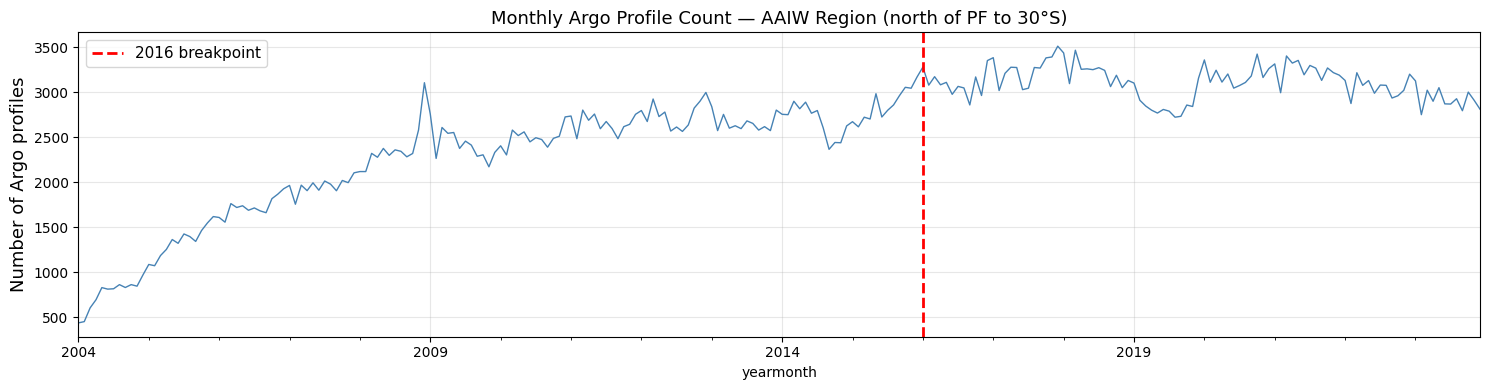

In [6]:
# Monthly profile count in Southern Ocean
so_aaiw = so[(so['lat'] >= -55) & (so['lat'] <= -30)]
so_aaiw['yearmonth'] = pd.to_datetime(
    so_aaiw['date'].dt.year.astype(str) + '-' +
    so_aaiw['date'].dt.month.astype(str).str.zfill(2)
)
monthly_counts = so_aaiw.groupby('yearmonth').size()

fig, ax = plt.subplots(figsize=(15, 4))
monthly_counts.plot(ax=ax, color='steelblue', lw=1)
ax.axvline(pd.Timestamp('2016-01-01'), color='red',
           ls='--', lw=2, label='2016 breakpoint')
# ax.axhspan(0, 50, color='red', alpha=0.05,
#            label='Sparse sampling (<50 profiles/month)')
ax.set_ylabel('Number of Argo profiles', fontsize=13)
ax.set_title('Monthly Argo Profile Count — AAIW Region (north of PF to 30°S)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/argo_profile_count_ts.jpg', dpi=500)

/tmp/ipykernel_308592/542753774.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  so_aaiw['month'] = so_aaiw['date'].dt.month


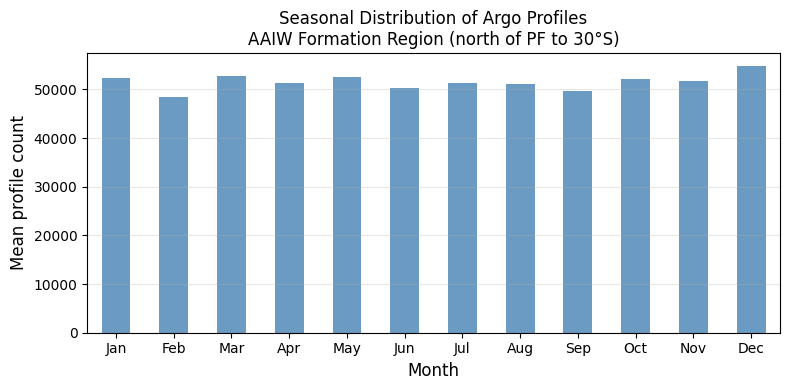

In [9]:
# Monthly profile count by season
so_aaiw = so[(so['lat'] >= -55) & (so['lat'] <= -30)]
so_aaiw['month'] = so_aaiw['date'].dt.month
monthly_mean = so_aaiw.groupby('month').size()

fig, ax = plt.subplots(figsize=(8, 4))
monthly_mean.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean profile count', fontsize=12)
ax.set_title('Seasonal Distribution of Argo Profiles\n'
             'AAIW Formation Region (north of PF to 30°S)', fontsize=12)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'],
                   rotation=0, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/argo_aaiw_region_seasonal_sampling.jpg', dpi=500)